#ANALISIS MARKET BASKET MENGGUNAKAN ALGORITMA APRIORI PADA DATA TRANSAKSI PENJUALAN BAKERY

## IMPORT PACKAGE

In [74]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Apriori & Association Rule
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [75]:
#Load Dataset
df = pd.read_csv('/content/drive/MyDrive/bread_basket.csv')

## DATA UNDERSTANDING

In [76]:
# Menampilkan 5 baris pertama dari DataFrame
df.head()

,Transaction,Item,date_time,Period Day,weekday_weekend
0,1,Bread,30/10/2016 9:58,morning,weekend
1,2,Scandinavian,30/10/2016 10:05,morning,weekend
2,2,Scandinavian,30/10/2016 10:05,morning,weekend
3,3,Hot chocolate,30/10/2016 10:07,morning,weekend
4,3,Jam,30/10/2016 10:07,morning,weekend


In [77]:
# Menampilkan 5 baris terakhir dari DataFrame
df.tail()

,Transaction,Item,date_time,Period Day,weekday_weekend
20502,9682,Coffee,9/04/2017 14:32,afternoon,weekend
20503,9682,Tea,9/04/2017 14:32,afternoon,weekend
20504,9683,Coffee,9/04/2017 14:57,afternoon,weekend
20505,9683,Pastry,9/04/2017 14:57,afternoon,weekend
20506,9684,Smoothies,9/04/2017 15:04,afternoon,weekend


In [78]:
# Menampilkan jumlah kolom dan baris dalam DataFrame
print("Dataset ini berisi %.f kolom dan %.f baris" %(df.shape[1], df.shape[0]))

Dataset ini berisi 5 kolom dan 20507 baris


Berdasarkan hasil output diatas, dataset yang digunakan dalam penelitian ini terdiri dari 5 kolom dan 20.507 baris data. Lima kolom tersebut merepresentasikan variabel-variabel yang digunakan dalam analisis, sedangkan 20.507 baris menunjukkan jumlah total transaksi yang tercatat dalam dataset. Jumlah data yang relatif besar ini menunjukkan bahwa dataset memiliki cakupan transaksi yang cukup luas.

In [79]:
# Menampilkan informasi tentang DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   Period Day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


Dataset ini memiliki tipe data yang beragam, yaitu:

- Transaction bertipe integer, yang merepresentasikan identitas transaksi.

- Item bertipe object, yang menunjukkan nama produk yang dibeli.

- date_time bertipe object, yang berisi informasi waktu transaksi.

- Period Day bertipe object, yang menunjukkan periode waktu dalam satu hari.

- weekday_weekend bertipe object, yang mengklasifikasikan hari menjadi hari kerja atau akhir pekan.

In [80]:
# Mengubah kolom date_time menjadi format datetime
df['date_time'] = pd.to_datetime(df['date_time'])

Kolom date_time diubah ke dalam format datetime. Hal ini dilakukan karena data waktu yang sebelumnya masih berupa teks, maka dari itu diubah menjadi format tanggal dan waktu yang tepat. Hal ini memungkinkan data waktu untuk diproses dan dianalisis dengan lebih mudah dan akurat.



In [81]:
# Jumlah Transaksi unik
df['Transaction'].nunique()

9465

Pada kolom transaksi menunjukkan bahwa terdapat 9.465 transaksi unik dalam dataset. Angka ini menandakan jumlah transaksi yang berbeda dan mengindikasikan bahwa satu transaksi dapat terdiri dari lebih dari satu item yang dibeli.

Tujuan dari penggunaan kodingan ini adalah untuk:

1. Mengetahui jumlah transaksi unik yang terdapat dalam dataset.

2. Memahami struktur data transaksi, khususnya hubungan antara transaksi dan item yang dibeli.

In [82]:
# Jumlah Item unik
df['Item'].nunique()

94

Pada kolom Item menunjukkan bahwa terdapat 94 item unik dalam dataset. Angka ini menggambarkan jumlah jenis produk yang tercatat dalam seluruh transaksi, sehingga menunjukkan variasi produk yang ditawarkan dan dibeli oleh pelanggan.

Tujuan dari penggunaan kodingan ini adalah untuk:

1. Mengetahui jumlah jenis item yang berbeda dalam dataset.

2. Memahami keragaman produk yang terlibat dalam transaksi.

In [83]:
# Melakukan ekstraksi dan transformasi fitur waktu (tanggal, jam, bulan, dan hari) dari date_time

df['Date'] = df['date_time'].dt.date

df['Time'] = df['date_time'].dt.time

df['Month'] = df['date_time'].dt.month
df['Month'] = df['Month'].replace((1,2,3,4,5,6,7,8,9,10,11,12),
              ('January','February','March','April','May','June','July',
               'August','September','October','November','December'))

df['Hour'] = df['date_time'].dt.hour
hour_in_num = (1,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)
hour_in_obj = ('1-2','7-8','8-9','9-10','10-11','11-12','12-13','13-14','14-15',
               '15-16','16-17','17-18','18-19','19-20','20-21','21-22','22-23','23-24')
df['Hour'] = df['Hour'].replace(hour_in_num, hour_in_obj)

df['Day'] = df['date_time'].dt.weekday
df['Day'] = df['Day'].replace((0,1,2,3,4,5,6),
                                          ('Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'))

df.drop('date_time', axis = 1, inplace = True)
df.drop('weekday_weekend', axis = 1, inplace = True)

Proses di atas bertujuan untuk melakukan transformasi dan ekstraksi fitur waktu dari kolom date_time. Informasi waktu yang semula berada dalam satu kolom dipecah menjadi beberapa kolom baru, yaitu Date, Time, Month, Hour, dan Day.

Kolom Month diubah dari bentuk numerik menjadi nama bulan agar lebih mudah dibaca dan dipahami. Selanjutnya, kolom Hour dikelompokkan ke dalam rentang jam tertentu untuk merepresentasikan interval waktu transaksi. Kolom Day juga dikonversi dari nilai numerik menjadi nama hari.

Setelah proses ekstraksi selesai, kolom date_time dan weekday_weekend dihapus karena informasinya telah direpresentasikan dalam kolom-kolom baru yang lebih spesifik.

In [113]:
# Menampilkan 5 baris pertama dari DataFrame
df.head()

,Transaction,Item,Period Day,Date,Time,Month,Hour,Day
0,1,Bread,morning,2016-10-30,09:58:00,October,9,Sunday
1,2,Scandinavian,morning,2016-10-30,10:05:00,October,10,Sunday
2,2,Scandinavian,morning,2016-10-30,10:05:00,October,10,Sunday
3,3,Hot chocolate,morning,2016-10-30,10:07:00,October,10,Sunday
4,3,Jam,morning,2016-10-30,10:07:00,October,10,Sunday


Tabel di atas adalah tampilan dataset setelah dilakukan proses transformasi dan ekstraksi fitur waktu. Setiap baris pada dataset merepresentasikan satu item yang dibeli dalam sebuah transaksi, sehingga satu nomor transaksi dapat muncul lebih dari satu kali apabila pelanggan membeli lebih dari satu item.

Berikut ini adalah penjelasan dari masing-masing kolom:

- Transaction menunjukkan identitas transaksi.

- Item merepresentasikan nama produk yang dibeli oleh pelanggan.

- Period Day menunjukkan periode waktu transaksi dalam satu hari, seperti pagi (morning).

- Date menunjukkan tanggal terjadinya transaksi.

- Time menunjukkan waktu transaksi secara spesifik.

- Month menunjukkan bulan terjadinya transaksi dalam bentuk teks.

- Hour menunjukkan rentang jam transaksi.

- Day menunjukkan hari transaksi dalam satu minggu.

### Data Visualization

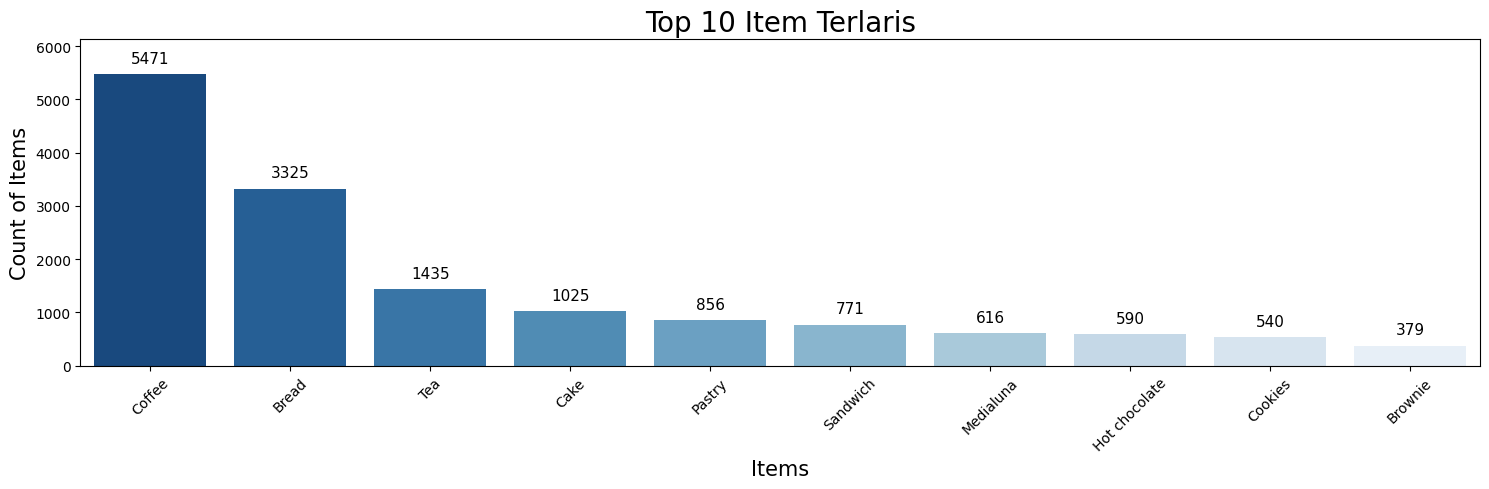

In [85]:
# Menampilkan visualisasi Top 10 item yang paling banyak dibeli oleh pelanggan
item_counts = df.Item.value_counts().head(10)
plt.figure(figsize=(15,5))
palette = sns.color_palette("Blues", n_colors=10)[::-1]

ax = sns.barplot(
    x=item_counts.index,
    y=item_counts.values,
    palette=palette
)

plt.xlabel('Items', size=15)
plt.ylabel('Count of Items', size=15)
plt.title('Top 10 Item Terlaris', size=20)
plt.xticks(rotation=45)

plt.ylim(0, item_counts.max() * 1.12)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 6),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

Gambar di atas menunjukkan 10 item yang paling sering dibeli oleh pelanggan berdasarkan jumlah kemunculan setiap item dalam data transaksi. Dari grafik tersebut dapat dilihat bahwa Coffee merupakan item dengan penjualan tertinggi, dengan jumlah pembelian mencapai 5.471 transaksi. Hal ini menunjukkan bahwa kopi menjadi produk paling populer dan memiliki permintaan paling tinggi dibandingkan item lainnya.

Posisi kedua dan ketiga ditempati oleh Bread dan Tea, yang juga memiliki jumlah penjualan cukup signifikan. Sementara itu, item seperti Cake, Pastry, Sandwich, Medialuna, Hot chocolate, Cookies, dan Brownie memiliki jumlah penjualan yang lebih rendah, namun tetap termasuk dalam kategori produk yang cukup diminati pelanggan.

Tujuan dibuatnya visualisasi ini adalah untuk:

1. Mengidentifikasi item yang paling laris berdasarkan data transaksi.

2. Mendukung pengambilan keputusan bisnis, seperti pengelolaan stok, penentuan produk unggulan, serta strategi promosi.

3. Menjadi dasar analisis association rule mining, untuk melihat keterkaitan antar item yang sering dibeli bersama.

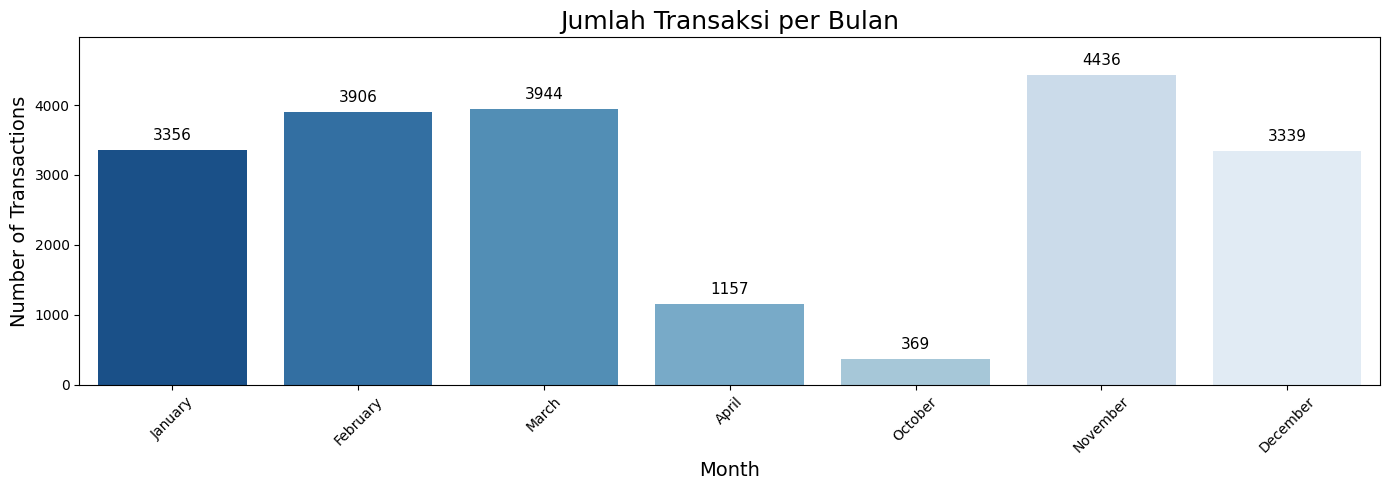

In [86]:
# Menampilkan visualisasi jumlah transaksi per bulan
monthly_transactions = df['Month'].value_counts().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]).dropna()

plt.figure(figsize=(14,5))
palette = sns.color_palette("Blues", n_colors=len(monthly_transactions))[::-1]

ax = sns.barplot(
    x=monthly_transactions.index,
    y=monthly_transactions.values,
    palette=palette
)

plt.xlabel('Month', size=14)
plt.ylabel('Number of Transactions', size=14)
plt.title('Jumlah Transaksi per Bulan', size=18)
plt.xticks(rotation=45)
plt.ylim(0, monthly_transactions.max() * 1.12)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

Gambar di atas menampilkan jumlah transaksi yang terjadi pada setiap bulan berdasarkan data yang tersedia. Dari grafik tersebut terlihat bahwa bulan November memiliki jumlah transaksi tertinggi, yaitu sebanyak 4.436 transaksi, yang menunjukkan adanya peningkatan aktivitas pembelian yang signifikan pada bulan tersebut.

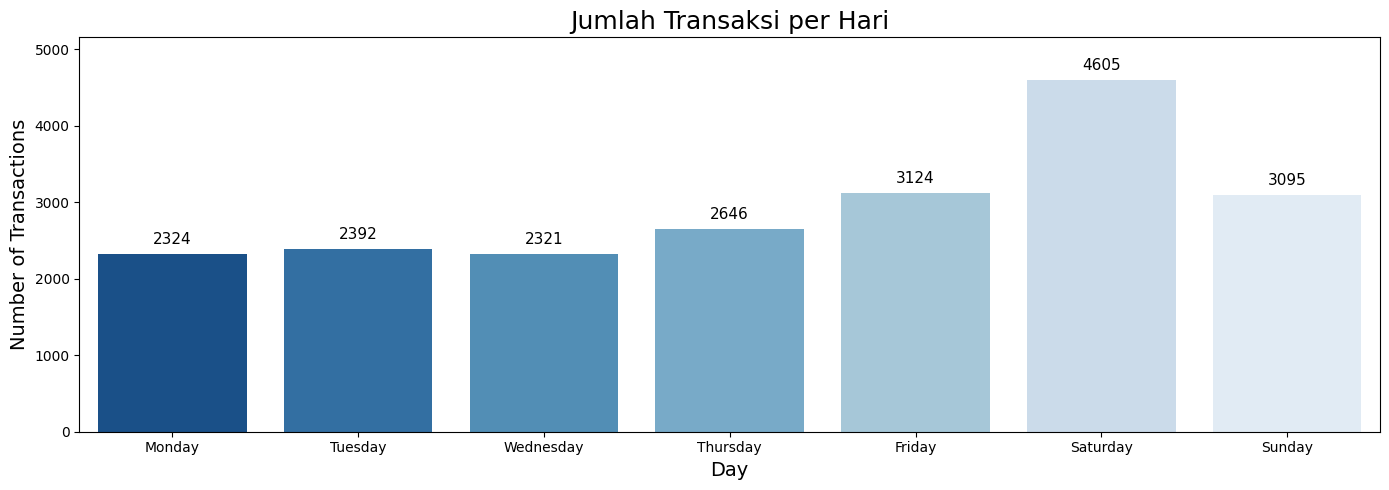

In [87]:
# Menampilkan visualisasi jumlah transaksi per hari
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_transactions = df['Day'].value_counts().reindex(day_order).dropna()
plt.figure(figsize=(14,5))
palette = sns.color_palette("Blues", n_colors=len(daily_transactions))[::-1]

ax = sns.barplot(
    x=daily_transactions.index,
    y=daily_transactions.values,
    palette=palette
)

plt.xlabel('Day', size=14)
plt.ylabel('Number of Transactions', size=14)
plt.title('Jumlah Transaksi per Hari', size=18)
plt.ylim(0, daily_transactions.max() * 1.12)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

Gambar di atas menunjukkan jumlah transaksi yang terjadi pada setiap hari dalam satu minggu. Berdasarkan grafik tersebut, dapat dilihat bahwa hari Sabtu memiliki jumlah transaksi tertinggi, yaitu sebanyak 4.605 transaksi, yang menandakan bahwa aktivitas pembelian paling ramai terjadi pada akhir pekan.

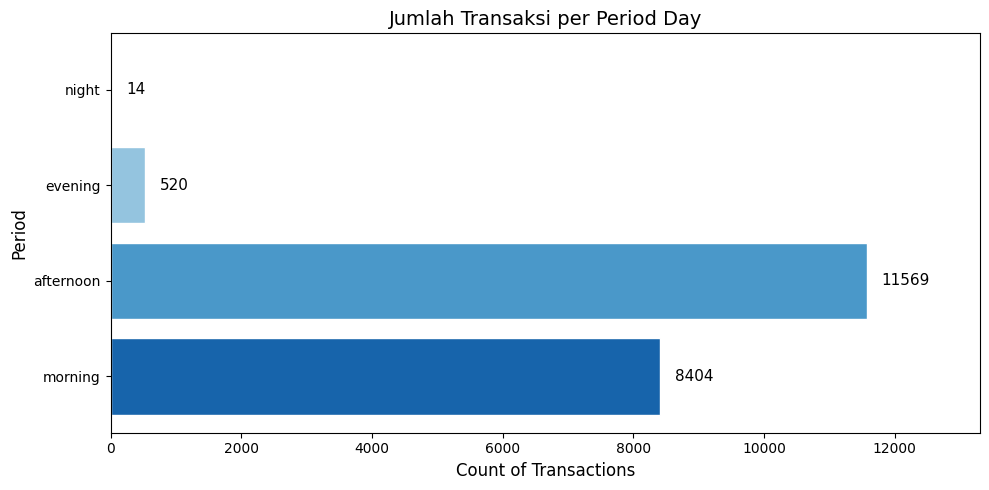

In [88]:
# Menampilkan visualisasi Jumlah Transaksi per Period Day
period_order = ['morning', 'afternoon', 'evening', 'night']
period_transactions = (
    df['Period Day']
    .value_counts()
    .reindex(period_order)
    .dropna()
)

colors = sns.color_palette("Blues", n_colors=len(period_transactions))[::-1]
plt.figure(figsize=(10,5))

bars = plt.barh(
    period_transactions.index,
    period_transactions.values,
    color=colors,
    edgecolor='white'
)

plt.xlabel('Count of Transactions', size=12)
plt.ylabel('Period', size=12)
plt.title('Jumlah Transaksi per Period Day', size=14)

max_value = period_transactions.max()
plt.xlim(0, max_value * 1.15)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max_value * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=11
    )

plt.grid(False)
plt.tight_layout()
plt.show()

Berdasarkan gambar diatas, dapat diketahui bahwa jumlah transaksi paling tinggi terjadi pada periode siang (afternoon) dengan total 11.569 transaksi. Hal ini menunjukkan bahwa aktivitas transaksi mencapai puncaknya pada waktu tersebut, ini bisa terjadi karena kemungkinan pelanggan lebih banyak di waktu siang hari.

Secara keseluruhan, pola distribusi transaksi memperlihatkan bahwa aktivitas transaksi sangat terkonsentrasi pada jam kerja, khususnya pada periode siang hari.

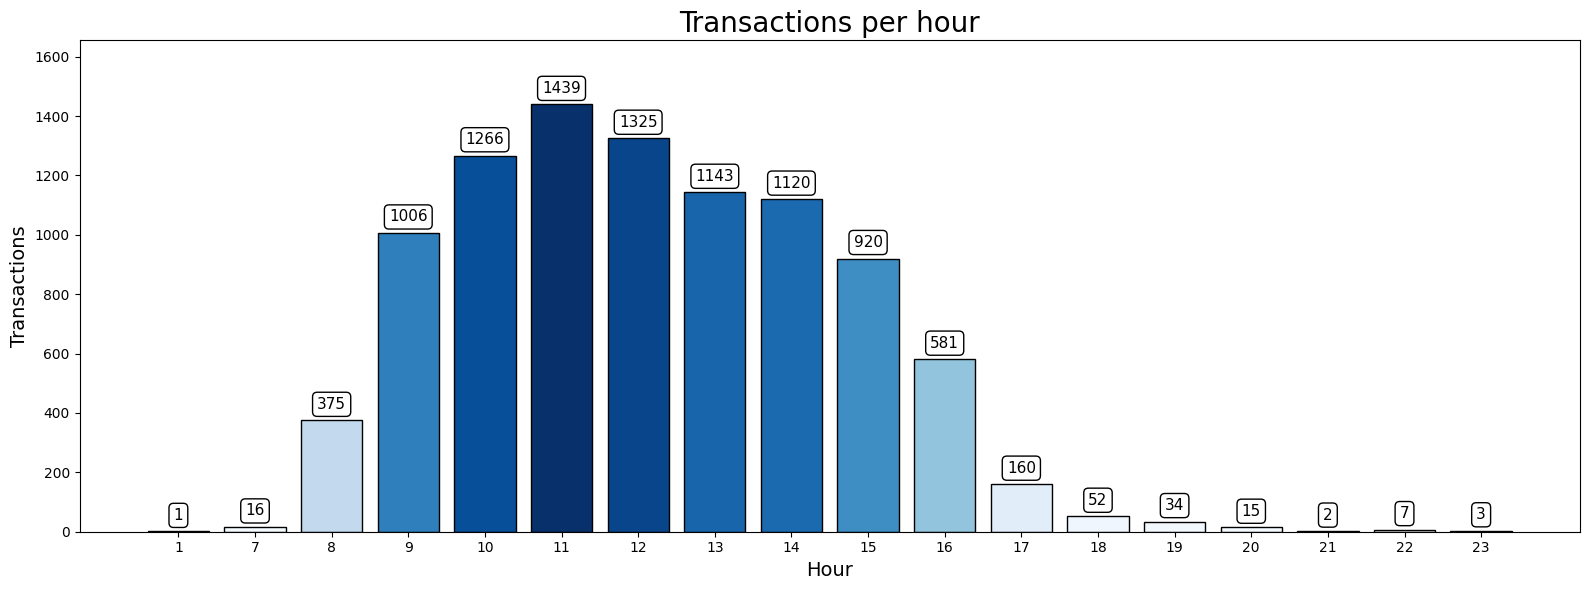

In [89]:
#Menampilkan visualisasi Jumlah Trasaksi per Jam
df['Hour'] = df['Time'].apply(lambda x: x.hour)

hourly_transactions = (
    df.groupby('Hour')['Transaction']
    .nunique()
    .reset_index(name='Transactions')
    .sort_values('Hour')
)

norm = plt.Normalize(
    hourly_transactions['Transactions'].min(),
    hourly_transactions['Transactions'].max()
)

cmap = plt.cm.Blues
colors = cmap(norm(hourly_transactions['Transactions']))

plt.figure(figsize=(16,6))

bars = plt.bar(
    hourly_transactions['Hour'].astype(str),
    hourly_transactions['Transactions'],
    color=colors,
    edgecolor='black'
)

plt.title('Transactions per hour', fontsize=20)
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Transactions', fontsize=14)

max_val = hourly_transactions['Transactions'].max()
plt.ylim(0, max_val * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max_val * 0.02,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='black'
        )
    )

plt.grid(False)
plt.tight_layout()
plt.show()

Visualisasi di atas menunjukkan distribusi jumlah transaksi berdasarkan jam dalam satu hari. Dari grafik tersebut terlihat bahwa aktivitas transaksi mulai meningkat secara signifikan sejak pukul 08.00, dengan jumlah transaksi sebesar 375, dan terus mengalami kenaikan hingga mencapai puncaknya pada pukul 11.00 dengan total 1.439 transaksi. Hal ini mengindikasikan bahwa periode tersebut merupakan jam paling aktif dalam penjualan.

Secara keseluruhan, pola distribusi ini menunjukkan bahwa mayoritas transaksi terkonsentrasi pada jam kerja pagi hingga siang hari, dengan puncak aktivitas terjadi menjelang tengah hari.

## DATA SELECTION

In [90]:
# Memilih kolom Transaction dan kolom Item
df_selected = df[['Transaction', 'Item']]
df_selected.head()

,Transaction,Item
0,1,Bread
1,2,Scandinavian
2,2,Scandinavian
3,3,Hot chocolate
4,3,Jam


Pada tahap data selection, dilakukan pemilihan kolom yaitu Transaction dan Item karena kedua atribut tersebut merupakan informasi inti yang dibutuhkan dalam analisis pola pembelian. Kolom Transaction berfungsi sebagai penanda setiap transaksi, sedangkan kolom Item merepresentasikan produk yang dibeli dalam transaksi tersebut.

 Hasil seleksi ini menghasilkan dataset yang merepresentasikan hubungan antara transaksi dan item, yang sangat penting sebagai dasar dalam analisis market basket dan pembentukan association rules pada tahap selanjutnya.

## DATA PREPARATION

In [91]:
# Menampilkan jumlah nilai yang hilang (missing value) pada setiap kolom
print("Menghitung missing value:")
print(df_selected.isnull().sum())

Menghitung missing value:
Transaction    0
Item           0
dtype: int64


Output di atas menunjukkan bahwa tidak terdapat missing value pada kolom Transaction dan Item. Kedua kolom memiliki jumlah nilai kosong sebesar 0, yang berarti seluruh data transaksi dan item tercatat secara lengkap tanpa ada data yang hilang.

Tujuan dilakukannya proses ini adalah untuk memeriksa kualitas data, khususnya untuk memastikan bahwa tidak ada nilai yang hilang (missing value) pada variabel utama yang akan digunakan dalam analisis. Pemeriksaan ini penting agar hasil analisis selanjutnya, seperti market basket analysis dan association rule mining, dapat dilakukan secara akurat tanpa bias atau kesalahan akibat data yang tidak lengkap.

In [92]:
# Menampilkan jumlah data duplikat dalam DataFrame
print('Data ini memiliki %.f data duplikat' %df_selected.duplicated().sum())

Data ini memiliki 1620 data duplikat


Dataset ini memiliki 1.620 data duplikat, yaitu baris data dengan kombinasi Transaction dan Item yang muncul lebih dari satu kali. Hal ini menandakan adanya pencatatan item yang sama secara berulang dalam transaksi yang sama.

In [93]:
#Menampilkan data duplikat berdasarkan Transaction dan Item
data_duplikat = df_selected[df_selected.duplicated(subset=['Transaction', 'Item'], keep=False)]
data_duplikat.sort_values(by=['Transaction', 'Item']).head(20)

,Transaction,Item
1,2,Scandinavian
2,2,Scandinavian
23,11,Bread
25,11,Bread
48,21,Coffee
49,21,Coffee
100,49,Coffee
101,49,Coffee
121,60,Coffee
123,60,Coffee


Output diatas menunjukan secara spesifik baris data yang terdapat duplikasi pada pasangan Transaction–Item. Proses ini dilakukan untuk memastikan bahwa duplikasi memang terjadi dalam transaksi yang sama, bukan antar transaksi yang berbeda dan memudahkan dalam proses analisis kualitas data sebelum dilakukan pembersihan data.

In [94]:
# Menampilkan Item yang sering muncul sebagai duplikat
duplikat_item_count = (
    data_duplikat
    .groupby('Item')
    .size()
    .sort_values(ascending=False)
)

duplikat_item_count.head(10)

,0
Item,
Coffee,1815
Bread,445
Sandwich,177
Tea,167
Cake,84
Pastry,81
Hot chocolate,74
Medialuna,60
Alfajores,50


Output di atas menunjukkan 10 item dengan jumlah data duplikat terbanyak dalam dataset transaksi.
Item Coffee memiliki jumlah duplikasi paling tinggi, yaitu 1.815 kali, diikuti oleh Bread (445), Sandwich (177), dan Tea (167).

Tingginya jumlah duplikasi pada item-item tersebut mengindikasikan bahwa dalam satu transaksi yang sama, item yang sama sering tercatat lebih dari satu kali. Hal ini dapat terjadi karena Item tersebut memang sering dibeli lebih dari satu unit dalam satu transaksi.

In [95]:
# Menampilkan tabel ringkasan data yang duplikat
summary_duplikat = (
    data_duplikat
    .groupby(['Transaction', 'Item'])
    .size()
    .reset_index(name='Jumlah Pembelian')
)

summary_duplikat.head()

,Transaction,Item,Jumlah Pembelian
0,2,Scandinavian,2
1,11,Bread,2
2,21,Coffee,2
3,49,Coffee,2
4,60,Coffee,2


Data di atas menunjukkan ringkasan data duplikat berdasarkan kombinasi Transaction dan Item. Kolom Jumlah Pembelian menunjukan berapa kali item yang sama muncul dalam satu transaksi yang sama. Hal ini dapat disimpulkan bahwa dalam satu transaksi, pelanggan dapat membeli lebih dari satu unit item yang sama.

Dengan demikian, data duplikat yang ditemukan bukan merupakan kesalahan, melainkan dapat merepresentasikan kuantitas pembelian item dalam satu transaksi.

In [96]:
# Menghapus Item yang sama dalam satu Transaksi
df_selected_clean = df_selected.drop_duplicates(
    subset=['Transaction', 'Item']
)

Proses di atas digunakan untuk menghapus data duplikat berdasarkan kolom Transaction dan Item, sehingga setiap item hanya tercatat satu kali dalam satu transaksi. Langkah ini dilakukan karena dalam analisis Market Basket Analysis, yang menjadi fokus utama adalah keberadaan suatu item dalam sebuah transaksi, bukan jumlah kemunculannya. Jika item yang sama muncul berulang dalam satu transaksi dan tidak dibersihkan, hal tersebut dapat menyebabkan perhitungan frekuensi item menjadi bias dan berdampak pada nilai support yang tidak akurat. Selain itu, langkah ini juga bertujuan untuk menyesuaikan struktur data dengan kebutuhan algoritma Apriori, sehingga proses pembentukan frequent itemsets dan association rules dapat menghasilkan pola yang lebih valid, akurat, dan mudah diinterpretasikan.

In [97]:
# Menampilkan jumlah data duplikat setelah dibersihkan
print('Jumlah data duplikat setelah dibersihkan:',
      df_selected_clean.duplicated(subset=['Transaction', 'Item']).sum())

Jumlah data duplikat setelah dibersihkan: 0


Terlihat bahwa setelah dilakukan proses pembersihan data dengan menghapus data duplikasi pada Kolom Transaction dan Item, tidak ditemukan lagi data duplikat dalam dataset.

In [98]:
# Menampilkan jumlah Data Duplikat sebelum dan sesudah di bersihkan
print('Jumlah data sebelum dibersihkan :', df_selected.shape[0])
print('Jumlah data setelah dibersihkan:', df_selected_clean.shape[0])

Jumlah data sebelum dibersihkan : 20507
Jumlah data setelah dibersihkan: 18887


Output di atas menunjukkan perbedaan jumlah data sebelum dan sesudah dilakukan proses pembersihan duplikasi. Sebelum dibersihkan, dataset df_selected memiliki 20.507 baris data, sedangkan setelah proses penghapusan data duplikat berdasarkan kombinasi Transaction dan Item, jumlah data berkurang menjadi 18.887 baris. Hal ini berarti terdapat 1.620 baris data duplikat yang berhasil diidentifikasi dan dihapus pada tahap sebelumnya. Pengurangan jumlah data ini merupakan hasil dari proses data cleaning yang bertujuan untuk memastikan bahwa setiap item hanya tercatat satu kali dalam setiap transaksi.

## DATA TRANSFORMATION

In [99]:
# Mengelompokan Item per Transaksi
transactions = (
    df_selected_clean
    .groupby('Transaction')['Item']
    .apply(list)
)

transactions.head(20)

,Item
Transaction,
1,[Bread]
2,[Scandinavian]
3,"[Hot chocolate, Jam, Cookies]"
4,[Muffin]
5,"[Coffee, Pastry, Bread]"
6,"[Medialuna, Pastry, Muffin]"
7,"[Medialuna, Pastry, Coffee, Tea]"
8,"[Pastry, Bread]"
9,"[Bread, Muffin]"


Output di atas menunjukan data yang telah di kelompokan berdasarkan setiap Transaction, kemudian menggabungkan seluruh Item yang dibeli dalam transaksi yang sama ke dalam sebuah list. Hasilnya, setiap baris berisi satu transaksi lengkap beserta kumpulan item yang dibeli secara bersamaan, bukan lagi satu baris per item seperti pada struktur data sebelumnya.

Sebelum transformasi, data masih berbentuk transaction–item (satu baris mewakili satu item dalam satu transaksi). Struktur ini belum dapat langsung digunakan untuk algoritma asosiasi seperti Apriori, karena algoritma tersebut membutuhkan data dalam bentuk kumpulan item per transaksi. Dengan proses groupby dan apply(list), data berhasil diubah menjadi format list of items per transaction yang lebih representatif terhadap perilaku belanja pelanggan.

In [100]:
# Mengubah data transaksi menjadi data biner (one-hot encoding) menggunakan TransactionEncoder
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


TransactionEncoder digunakan untuk melakukan one-hot encoding, yaitu mengonversi setiap item menjadi sebuah kolom, sementara setiap baris merepresentasikan satu transaksi. Jika suatu item muncul dalam sebuah transaksi, maka nilainya bernilai True, dan jika tidak muncul maka bernilai False. Proses ini dibuat karena algoritma Apriori tidak dapat langsung bekerja dengan data berbentuk teks atau list, melainkan membutuhkan data biner (0/1 atau True/False) untuk menghitung support, confidence, dan lift. Dengan melakukan encoding ini, dataset menjadi terstruktur secara matematis, siap digunakan untuk mengekstraksi pola kombinasi item dan membangun aturan asosiasi secara akurat.

In [101]:
# Mengonversi hasil encoding ke tipe data integer (0 dan 1)
df_encoded = df_encoded.astype(int)
df_encoded.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## DATA MINING

In [102]:
# Penerapan algoritma Apriori untuk menentukan frequent itemsets
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets

,support,itemsets
0,0.036344,(Alfajores)
1,0.016059,(Baguette)
2,0.327205,(Bread)
3,0.040042,(Brownie)
4,0.103856,(Cake)
...,...,...
56,0.023666,"(Coffee, Toast)"
57,0.014369,"(Tea, Sandwich)"
58,0.010037,"(Coffee, Cake, Bread)"
59,0.011199,"(Coffee, Pastry, Bread)"


Proses di atas merupakan tahap data mining, tepatnya penerapan algoritma Apriori untuk menemukan frequent itemsets atau kombinasi item yang sering muncul dalam satu transaksi. Data yang digunakan adalah data yang sebelumnya telah melalui proses one-hot encoding, sehingga setiap item direpresentasikan dalam bentuk biner yang sesuai dengan kebutuhan algoritma Apriori. Parameter support yang digunakan adalah 0.01 yang menunjukan hanya kombinasi item yang muncul minimal pada 1% dari seluruh transaksi yang akan ditampilkan, sehingga pola yang terlalu jarang dapat diabaikan

Tujuan dari proses ini adalah untuk mengetahui pola pembelian pelanggan, yaitu item apa saja yang sering dibeli bersama. Hasil frequent itemsets ini menjadi dasar untuk analisis lanjutan seperti pembuatan aturan asosiasi (association rules).

In [103]:
# Menampilkan 10 frequent itemsets dengan nilai support tertinggi
frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

,support,itemsets
6,0.478394,(Coffee)
2,0.327205,(Bread)
26,0.142631,(Tea)
4,0.103856,(Cake)
34,0.090016,"(Coffee, Bread)"
19,0.086107,(Pastry)
21,0.071844,(Sandwich)
16,0.061807,(Medialuna)
12,0.058320,(Hot chocolate)
42,0.054728,"(Coffee, Cake)"


Data diatas hasil frequent itemsets berdasarkan nilai support dari yang terbesar ke yang terkecil. Nilai support menunjukkan seberapa sering suatu item atau kombinasi item muncul dalam seluruh transaksi.

Tujuan dari proses ini adalah untuk mengidentifikasi item dan kombinasi item yang paling dominan dalam data transaksi. Dengan mengetahui frequent itemsets dengan support tertinggi, kita dapat mengetahui bahwa coffee adalah item yang paling sering dibeli pelanggan.

In [104]:
# Menampilkan frequent itemsets yang memiliki support tertinggi
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

frequent_itemsets[
    frequent_itemsets['length'] >= 2
].sort_values(by='support', ascending=False).head()

,support,itemsets,length
34,0.090016,"(Coffee, Bread)",2
42,0.054728,"(Coffee, Cake)",2
55,0.049868,"(Coffee, Tea)",2
50,0.047544,"(Coffee, Pastry)",2
51,0.038246,"(Coffee, Sandwich)",2


Proses di atas digunakan untuk menyeleksi dan menganalisis kombinasi produk yang terdiri dari dua item atau lebih dalam hasil frequent itemsets.

Tujuan dari langkah ini adalah untuk menemukan pola pembelian bersama (co-purchase), karena kombinasi yang terdiri dari beberapa item memberikan informasi yang lebih bernilai dibandingkan pembelian satu item saja.

### Association Rule

In [105]:
# Membentuk association rules dari frequent itemsets
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.3
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
1,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.000985,1.017305,0.036980,0.075908,0.017011,0.213884
2,(Brownie),(Coffee),0.040042,0.478394,0.019651,0.490765,1.025860,1.0,0.000495,1.024293,0.026259,0.039398,0.023717,0.265921
3,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
4,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


Proses di atas merupakan tahap association rule, yang dilakukan setelah memperoleh kombinasi item yang sering muncul pada tahap sebelumnya. Pada langkah ini, kombinasi item yang telah ditemukan digunakan untuk membentuk aturan asosiasi, yaitu hubungan jika–maka antar item dalam transaksi. Nilai confidence digunakan sebagai ukuran utama untuk menilai seberapa kuat hubungan tersebut, dengan batas minimum sebesar 0,3. Artinya, sebuah aturan hanya akan digunakan jika peluang munculnya item lain saat suatu item dibeli mencapai minimal 30%.

Hal ini bertujuan untuk mengidentifikasi pola hubungan antar produk yang memiliki tingkat kepercayaan cukup tinggi. Dengan menghubungkan hasil frequent itemsets ke aturan asosiasi, proses ini tidak hanya menunjukkan item apa saja yang sering dibeli bersama, tetapi juga seberapa besar kemungkinan pelanggan membeli suatu item ketika membeli item lainnya.

In [106]:
# Menampilkan jumlah total association rules
print("Jumlah association rules:", rules.shape[0])

Jumlah association rules: 19


## EVALUATION

In [107]:
# Memfilter association rules yang kuat berdasarkan lift dan confidence
rules[
    (rules['lift'] > 1) &
    (rules['confidence'] >= 0.5)
].sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
13,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
7,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
9,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
0,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
6,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
10,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
3,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
11,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
4,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


Pada tahap evaluasi, proses ini dilakukan untuk menyaring hasil aturan hubungan antar produk yang telah diperoleh dari tahap sebelumnya agar hanya aturan yang benar-benar kuat dan bermakna yang digunakan. Dari sekian banyak aturan yang dihasilkan, tidak semuanya memiliki kualitas yang baik, sehingga perlu dilakukan pemilihan berdasarkan ukuran tertentu.

Nilai confidence ≥ 0,5 digunakan untuk memastikan bahwa aturan yang dipilih memiliki tingkat kepercayaan yang tinggi. Artinya, ketika suatu item dibeli, kemungkinan item lain ikut dibeli setidaknya sebesar 50%. Sementara itu, lift > 1 digunakan untuk mengukur kekuatan hubungan antar item. Nilai lift yang lebih besar dari 1 menunjukkan bahwa keterkaitan antar item terjadi karena adanya hubungan nyata, bukan sekadar kebetulan.

Aturan yang telah lolos kedua kriteria tersebut kemudian diurutkan berdasarkan nilai lift dari yang terbesar. Hal ini bertujuan untuk menampilkan aturan dengan hubungan paling kuat dan paling bermakna terlebih dahulu.

In [108]:
#Menampilkan Top 10 Association Rules
top_rules = rules[
    (rules['lift'] > 1) &
    (rules['confidence'] >= 0.5)
].sort_values(by='lift', ascending=False).head(10)

top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
13,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
7,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
9,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
0,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
6,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
10,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
3,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
11,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
4,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


In [109]:
# Menampilkan jumlah total association rules
print("Jumlah Top Rules:", top_rules.shape[0])

Jumlah Top Rules: 10


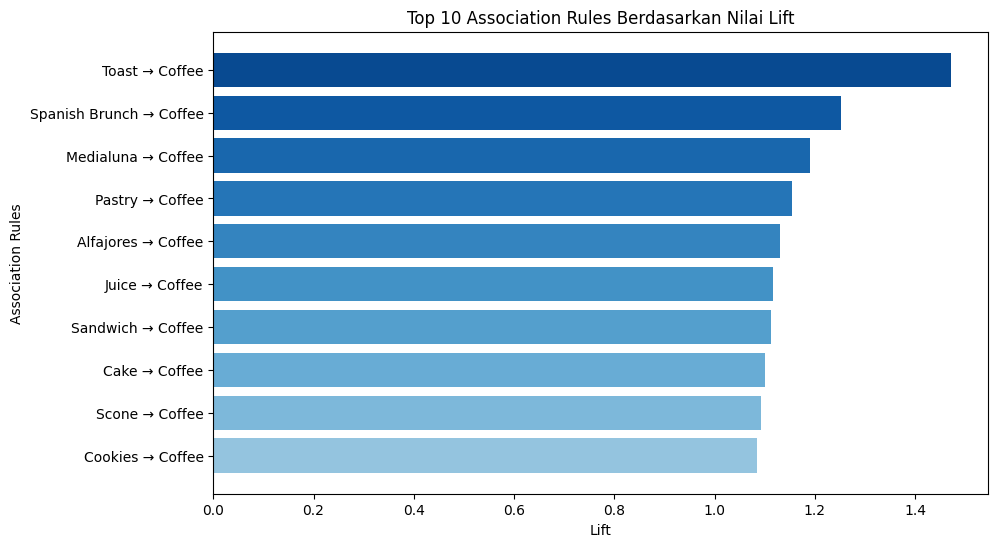

In [110]:
# Visualisasi To 10 Association Rules
import matplotlib.pyplot as plt
import numpy as np

rule_labels = top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + \
              ' → ' + \
              top_rules['consequents'].apply(lambda x: ', '.join(list(x)))

colors = plt.cm.Blues(
    np.linspace(0.9, 0.4, len(top_rules))
)

plt.figure(figsize=(10,6))
plt.barh(rule_labels, top_rules['lift'], color=colors)
plt.xlabel('Lift')
plt.ylabel('Association Rules')
plt.title('Top 10 Association Rules Berdasarkan Nilai Lift')
plt.gca().invert_yaxis()
plt.show()

## INTERPRETATION

Berdasarkan hasil association rule yang telah diseleksi menggunakan confidence ≥ 0.5 dan lift > 1, diperoleh beberapa aturan asosiasi yang menunjukkan hubungan kuat dan signifikan antara produk tertentu dengan produk Coffee.

Secara umum, seluruh aturan menunjukkan pola:

- Jika pelanggan membeli suatu produk tertentu, maka pelanggan cenderung juga membeli Coffee.

Pasangan Item yang paling sering muncul dalam Top 10 aturan tersebut adalah:

1. Toast dan Coffee
2. Spanish Brunch dan Coffee
3. Medialuna dan Coffee
4. Pastry dan Coffee
5. Alfajores dan Coffee
6. Juice dan Coffee
7. Sandwich dan Coffee
8. Cake dan Coffee
9. Scone dan Coffee
10. Cookies dan Coffee

Hal ini menunjukkan bahwa Coffee memiliki tingkat keterkaitan yang tinggi terhadap berbagai jenis makanan, baik makanan berat maupun makanan ringan.

In [111]:
def search_association(product_a, product_b, rules_df):
    product_a = product_a.lower()
    product_b = product_b.lower()

    # Cari aturan A → B
    result = rules_df[
        rules_df['antecedents'].apply(lambda x: product_a in [i.lower() for i in x]) &
        rules_df['consequents'].apply(lambda x: product_b in [i.lower() for i in x])
    ]

    if result.empty:
        print(f"Tidak ditemukan hubungan pembelian antara {product_a.title()} dan {product_b.title()}.")
        return

    row = result.iloc[0]
    confidence = row['confidence']
    lift = row['lift']

    print("🔍 HASIL ANALISIS ASSOCIATION RULE\n")
    print(f"Produk A   : {product_a.title()}")
    print(f"Produk B   : {product_b.title()}")
    print(f"Confidence : {confidence:.2f}")
    print(f"Lift       : {lift:.2f}")

    print("\n💡 BUSINESS INSIGHT:")

    # INSIGHT DINAMIS (menyebut nama produk)
    if confidence >= 0.6 and lift >= 1.2:
        print(f"Produk {product_a.title()} dan {product_b.title()} sangat sering dibeli secara bersamaan, "
              f"sehingga cocok untuk diterapkan strategi Bundling Produk.")
        print("Kombinasi produk ini cocok digunakan dalam promo bersama untuk mendorong pelanggan membeli lebih banyak dalam satu transaksi.")

        print("Strategi Bundling Produk adalah strategi pemasaran dengan menggabungkan dua atau lebih produk yang sering dibeli bersamaan dan menjualnya dalam satu paket.")

        print("Tujuannya:")
        print("- Membuat pelanggan lebih tertarik membeli")
        print("- Meningkatkan jumlah pembelian dalam satu transaksi")


    elif confidence >= 0.5 and lift > 1:
        print(
            f"Pelanggan yang membeli {product_a.title()} cenderung juga membeli {product_b.title()}, "
            f"sehingga dapat dimanfaatkan untuk strategi Cross-selling.")
        print("Cross-selling adalah strategi menawarkan produk tambahan kepada pelanggan saat mereka sudah membeli satu produk utama.")
        print("Fokusnya bukan paket, tapi rekomendasi produk pelengkap.")

    else:
        print(
            f"Pola pembelian menunjukkan bahwa {product_a.title()} dan {product_b.title()} sering dibeli bersamaan, "
            f"sehingga penempatan produk secara berdekatan berpotensi untuk mendorong penjualan.")
        print("Penempatan produk berdekatan bertujuan untuk:")
        print("- Mempermudah pelanggan menemukan produk pelengkap")
        print("- Meningkatkan peluang pembelian spontan (impulse buying)")

In [112]:
produk_a = input("Masukkan Produk A: ")
produk_b = input("Masukkan Produk B: ")

search_association(produk_a, produk_b, rules)

Masukkan Produk A: cake
Masukkan Produk B: coffee
🔍 HASIL ANALISIS ASSOCIATION RULE

Produk A   : Cake
Produk B   : Coffee
Confidence : 0.53
Lift       : 1.10

💡 BUSINESS INSIGHT:
Pelanggan yang membeli Cake cenderung juga membeli Coffee, sehingga dapat dimanfaatkan untuk strategi Cross-selling.
Cross-selling adalah strategi menawarkan produk tambahan kepada pelanggan saat mereka sudah membeli satu produk utama.
Fokusnya bukan paket, tapi rekomendasi produk pelengkap.
